# 내적을 토대로 벡터들 관계 규정짓기-07강 4기 19강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, lam = sp.symbols("x lambda", real=True)

## 1. 근의 공식을 말로 유도하기
$a\neq 0$ 인 $ax^2+bx+c=0$ 의 일반해를 기호로 끌어냅니다.

In [2]:
a, b, c = sp.symbols("a b c")
print("ax²+bx+c=0  ->  x =", sp.solve(a * x**2 + b * x + c, x))

ax²+bx+c=0  ->  x = [(-b - sqrt(-4*a*c + b**2))/(2*a), (-b + sqrt(-4*a*c + b**2))/(2*a)]


## 2. 근의 공식 적용 · 완전제곱식 만들기
구체적 2차식의 근, 그리고 `3x² + 6x = 3(x+1)² − 3` 완전제곱 검산.

In [3]:
for q in [x**2 - 4*x + 1, x**2 - 4*x + 3, x**2 - 6*x + 9, 2*x**2 - 4*x + 2]:
    print(f"{str(q):>16} = 0  ->  x = {sp.solve(sp.Eq(q, 0), x)}")
print("complete square 3x²+6x :", sp.expand(3*(x + 1)**2 - 3), "==", sp.expand(3*x**2 + 6*x))

  x**2 - 4*x + 1 = 0  ->  x = [2 - sqrt(3), sqrt(3) + 2]
  x**2 - 4*x + 3 = 0  ->  x = [1, 3]
  x**2 - 6*x + 9 = 0  ->  x = [3]
2*x**2 - 4*x + 2 = 0  ->  x = [1]
complete square 3x²+6x : 3*x**2 + 6*x == 3*x**2 + 6*x


## 3. 고유치를 구하는 레시피 — 특성 방정식
"대각선에서 $\lambda$ 를 빼고 $\det = 0$." 즉 $\det(A-\lambda I)=0$ 을 풀면 고유치가 나옵니다.

In [4]:
A = sp.Matrix([[2, 1], [3, 2]])
print("A - λI   =", (A - lam * sp.eye(2)).tolist())
print("det(A-λI) =", sp.expand((A - lam * sp.eye(2)).det()), "= 0")
print("λ        =", sp.solve((A - lam * sp.eye(2)).det(), lam))

A - λI   = [[2 - lambda, 1], [3, 2 - lambda]]
det(A-λI) = lambda**2 - 4*lambda + 1 = 0
λ        = [2 - sqrt(3), sqrt(3) + 2]


## 4. 특성 방정식·전개·고유치·고유 벡터 집중 연습
강의의 예시 행렬 그대로. 마지막 `[[0,2],[-2,0]]` 은 고유치가 `±2i` (복소수).

In [5]:
examples = {
    "[[1,1],[1,1]]": sp.Matrix([[1, 1], [1, 1]]),
    "[[2,1],[3,2]]": sp.Matrix([[2, 1], [3, 2]]),
    "[[0,1],[1,0]]": sp.Matrix([[0, 1], [1, 0]]),
    "[[0,2],[-2,0]]": sp.Matrix([[0, 2], [-2, 0]]),
}
for name, Mx in examples.items():
    cp = sp.factor((Mx - lam * sp.eye(2)).det())
    print(f"{name:>16}:  det = {cp} = 0   ->  eigenvalues {list(Mx.eigenvals().keys())}")

   [[1,1],[1,1]]:  det = lambda*(lambda - 2) = 0   ->  eigenvalues [2, 0]
   [[2,1],[3,2]]:  det = lambda**2 - 4*lambda + 1 = 0   ->  eigenvalues [2 - sqrt(3), sqrt(3) + 2]
   [[0,1],[1,0]]:  det = (lambda - 1)*(lambda + 1) = 0   ->  eigenvalues [-1, 1]
  [[0,2],[-2,0]]:  det = lambda**2 + 4 = 0   ->  eigenvalues [-2*I, 2*I]


## 7. 내적은 함수다 — 정의역과 공역
$\langle\cdot,\cdot\rangle:\mathbb{R}^2\times\mathbb{R}^2\to\mathbb{R}$, 즉 두 벡터에 **실수 하나**를 매기는 함수.
대각 내적 $M=\mathrm{diag}(\lambda_1,\lambda_2)$ 로 두면 $\langle u,v\rangle_M = u^\top M v$.

In [6]:
def ip(u, v, M):   return float(u @ M @ v)
def norm(v, M):    return np.sqrt(ip(v, v, M))
def angle_deg(u, v, M):
    return np.degrees(np.arccos(np.clip(ip(u, v, M) / (norm(u, M) * norm(v, M)), -1, 1)))

u, v = np.array([2.0, 0.6]), np.array([0.7, 1.9])
print("standard <u,v> =", ip(u, v, np.eye(2)), "(a single real number)")

standard <u,v> = 2.54 (a single real number)


## 8. 내적이 그리는 심상 — 정사영과 두 크기의 곱
$\langle u,v\rangle = \|u\|\cdot(\text{v를 u에 정사영한 길이}) = \|u\|\,\|v\|\cos\theta$.

In [7]:
us, vs, I = np.array([3.2, 0.9]), np.array([1.3, 2.5]), np.eye(2)
projlen = ip(us, vs, I) / norm(us, I)                       # length of v projected onto u
print(f"<u,v> = {ip(us,vs,I):.2f}")
print(f"|u| × (proj length) = {norm(us,I):.2f} × {projlen:.3f} = {norm(us,I)*projlen:.2f}")
print(f"|u||v|cosθ          = {norm(us,I)*norm(vs,I)*np.cos(np.radians(angle_deg(us,vs,I))):.2f}")

<u,v> = 6.41
|u| × (proj length) = 3.32 × 1.928 = 6.41
|u||v|cosθ          = 6.41


## 10. 내적에서 크기와 각도가 따라 나온다
$\|v\|=\sqrt{\langle v,v\rangle}$, $\cos\theta=\dfrac{\langle u,v\rangle}{\|u\|\|v\|}$.
같은 좌표 $u,v$ 라도 내적 $M$ 을 바꾸면 크기·각도가 달라지고, 단위원 $\{x:\langle x,x\rangle=1\}$ 이 **원→타원**으로 바뀝니다.

In [8]:
for label, M in {"standard I": np.eye(2), "diagonal diag(1,3)": np.diag([1.0, 3.0])}.items():
    print(f"{label:>18}:  <u,v>={ip(u,v,M):5.2f}   |u|={norm(u,M):4.2f}   |v|={norm(v,M):4.2f}   angle={angle_deg(u,v,M):5.1f} deg")

        standard I:  <u,v>= 2.54   |u|=2.09   |v|=2.02   angle= 53.1 deg
diagonal diag(1,3):  <u,v>= 4.82   |u|=2.25   |v|=3.36   angle= 50.5 deg


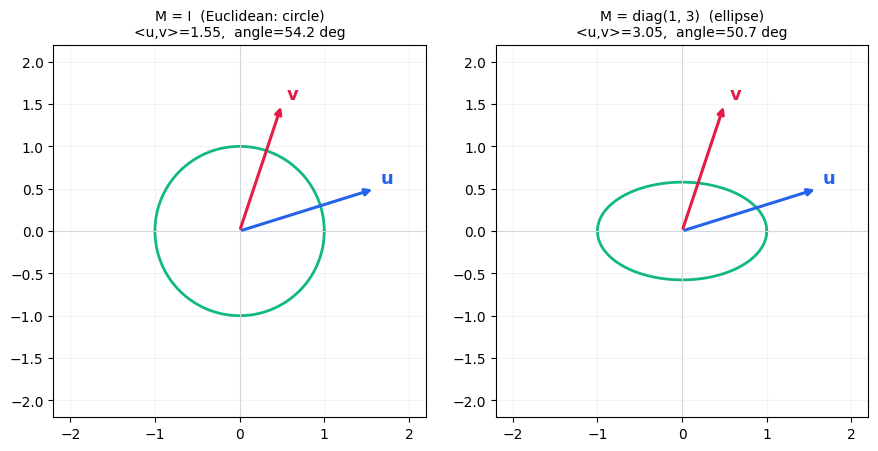

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
uu, vv = np.array([1.6, 0.5]), np.array([0.5, 1.5])
phi = np.linspace(0, 2 * np.pi, 240)
for ax, (title, l1, l2) in zip(axes, [("M = I  (Euclidean: circle)", 1.0, 1.0),
                                       ("M = diag(1, 3)  (ellipse)", 1.0, 3.0)]):
    ax.plot(np.cos(phi) / np.sqrt(l1), np.sin(phi) / np.sqrt(l2), color="#10b981", lw=2)  # unit ball
    Md = np.diag([l1, l2])
    for vec, color, name in [(uu, "#2563eb", "u"), (vv, "#e11d48", "v")]:
        ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2))
        ax.text(vec[0] + .06, vec[1] + .06, name, color=color, fontsize=13, weight="bold")
    ax.set_title(f"{title}\n<u,v>={ip(uu,vv,Md):.2f},  angle={angle_deg(uu,vv,Md):.1f} deg", fontsize=10)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
    ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
    ax.grid(alpha=.15)
fig.tight_layout()
plt.show()

## 11. 고유치·고유 벡터의 정체 — 내적을 대각 행렬로 적기
대칭 양의정부호 $M$ 을 대각화하면 $M=Q\,\mathrm{diag}(\lambda)\,Q^\top$.
고유 벡터 $q_i$ 는 정규직교이고, **그 M-크기의 제곱이 곧 고유치**: $\langle q_i,q_i\rangle_M=\lambda_i$.
또 "회전행렬" $R(\theta)$ 는 $R^\top R=I,\ \det R=1$ (이 '회전' 해석은 유클리드 기준에서만 맞는 고유명사).

In [10]:
M = np.array([[2.0, 1.0], [1.0, 2.0]])
w, Q = np.linalg.eigh(M)                       # eigenvalues w, orthonormal eigenvectors (columns of Q)
print("eigenvalues lambda =", np.round(w, 4))
print("Qt Q = I ?\n", np.round(Q.T @ Q, 9))
for i in range(2):
    q = Q[:, i]
    print(f"  q{i+1}={np.round(q,3)}   |q{i+1}|_M^2 = qt M q = {q @ M @ q:.3f}   (= lambda{i+1} = {w[i]:.3f})")

th = sp.pi / 5
R = sp.Matrix([[sp.cos(th), -sp.sin(th)], [sp.sin(th), sp.cos(th)]])
print("R(th)^T R(th) =", sp.simplify(R.T @ R).tolist(), "  det R =", sp.simplify(R.det()))

eigenvalues lambda = [1. 3.]
Qt Q = I ?
 [[1. 0.]
 [0. 1.]]
  q1=[-0.707  0.707]   |q1|_M^2 = qt M q = 1.000   (= lambda1 = 1.000)
  q2=[0.707 0.707]   |q2|_M^2 = qt M q = 3.000   (= lambda2 = 3.000)
R(th)^T R(th) = [[1, 0], [0, 1]]   det R = 1
